In [2]:
#Importing All the Needed Libraries
%reset -f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from scipy import stats



In [3]:
df = pd.read_excel('1 Radio Lab RF chain.xlsx',sheet_name = "Filter")

# Step 2: Extract Frequency and Voltage columns
frequency = df['Frequency']
#voltage = df['V(mV)']
voltage = df['Gain']

In [23]:
# Load the Excel file
file_path = 'extracted_data.xlsx'  # Replace with your file path
df = pd.read_excel(file_path)
print(df)

   Unnamed: 0  wavelength  Group1_Epidote1  Group2_Gypsum1  Group3_Limonite1  \
0           0         470            0.103           0.189             0.053   
1           1         555            0.148           0.209             0.072   
2           2         585            0.153           0.214             0.083   
3           3         605            0.155           0.216             0.084   
4           4         635            0.161           0.220             0.083   
5           5         660            0.168           0.222             0.084   
6           6         695            0.181           0.225             0.087   
7           7         880            0.197           0.229             0.083   
8           8         940            0.198           0.224             0.083   

   Group4_Realgar1  Group5_Hornblende1  Group6_Pyrite1  
0            0.072               0.052           0.082  
1            0.081               0.059           0.101  
2            0.103          

In [6]:

# Extract columns 'x' and 'y'
x_column = df['Frequency'].values  # Replace 'x' with the exact name of the column in the Excel file
y_column = df['Gain'].values  # Replace 'y' with the exact name of the column in the Excel file

# Print or work with the extracted columns
print(x_column)
print(y_column)


[ 20  40  60  80 100 120 140 160 180 200 220 240 260 280 300 320 340 360
 380 400 420 440 460 480 500 520 540 560 580 600 620 640 660 680 700 720
 740 760 780 800]
[ -0.14  -0.13  -0.15  -0.27  -0.33  -0.24  -0.36  -0.51  -0.3   -0.36
  -0.66  -0.53  -0.35  -0.65  -0.75  -0.6   -0.67  -0.96  -0.83  -1.
  -1.26  -1.25  -1.34  -1.92  -2.39  -2.54  -3.43  -5.23  -7.21  -9.05
 -14.26 -21.   -23.51 -25.6  -32.33 -38.88 -41.1  -37.25 -33.6  -32.74]


In [7]:
def find_x_for_y(x_values, y_values, target_y, tolerance=1e-6):
    """
    Find all x values corresponding to a specific y value, including interpolated values.

    Args:
    x_values (np.array): Array of x values.
    y_values (np.array): Array of y values (e.g., sin(x)).
    target_y (float): The target y value to find the corresponding x value(s) for.
    tolerance (float): Tolerance to handle floating-point comparisons.

    Returns:
    np.array: Array of x values corresponding to the target_y.
    """
    # Ensure x and y are numpy arrays
    x_values = np.asarray(x_values)
    y_values = np.asarray(y_values)

    # Find indices where the exact y values match (within tolerance)
    exact_indices = np.where(np.abs(y_values - target_y) <= tolerance)[0]
    
    # Initialize list to store found x values
    x_results = x_values[exact_indices].tolist()
    
    # Sort x and y values for interpolation (if not already sorted)
    sorted_indices = np.argsort(x_values)
    sorted_x = x_values[sorted_indices]
    sorted_y = y_values[sorted_indices]

    # Interpolate function
    interp_func = interp1d(sorted_y, sorted_x, bounds_error=False, fill_value="extrapolate", kind='linear')

    # Check interpolation results between every pair of points
    for i in range(len(sorted_y) - 1):
        # If the target y is between sorted_y[i] and sorted_y[i+1], interpolate
        if (sorted_y[i] <= target_y <= sorted_y[i+1]) or (sorted_y[i] >= target_y >= sorted_y[i+1]):
            x_interpolated = interp_func(target_y)
            x_results.append(x_interpolated)
    
    # Remove duplicates and return sorted x values
    return np.unique(x_results)

X values corresponding to max_gain = -0.09: [20.]
X values corresponding to y = [-3.09]: [526.4084507]


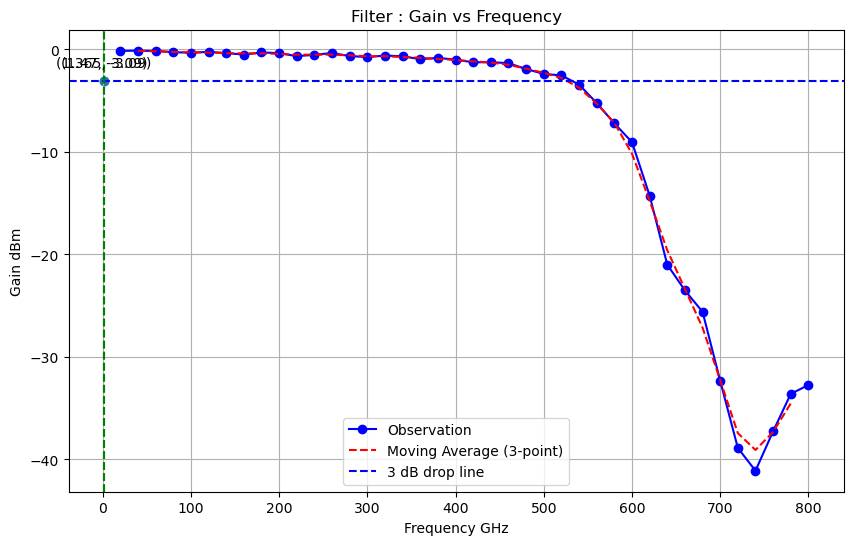

In [14]:


# Function to calculate moving average
def moving_average(y_values, window_size=3):
    """
    Calculate moving average with a specified window size.
    By default, a 3-point moving average is used.

    Args:
    y_values (list or np.array): List or array of y-values.
    window_size (int): The window size for the moving average.

    Returns:
    np.array: The moving average values with NaN for points that don't have enough neighbors.
    """
    return np.convolve(y_values, np.ones(window_size) / window_size, mode='same')


# Calculate the moving average with a 3-point window
y_moving_avg = moving_average(y_column, window_size=3)

# Find the maximum gain
max_gain = np.max(y_moving_avg)

# Calculate the 3 dBm drop from the maximum gain
drop_3db = float(max_gain - 3)

# Find the x value(s) for a specific interpolated y value, say y = 13 and y = 11
target_y = [drop_3db]

x_for_target_y = find_x_for_y(x_column, y_moving_avg, max_gain)

print(f"X values corresponding to max_gain = {max_gain}: {x_for_target_y}")

target_y = [drop_3db]

x_for_target_y = find_x_for_y(x_column, y_moving_avg, target_y)

print(f"X values corresponding to y = {target_y}: {x_for_target_y}")



# Plot original 'y' values and moving average
plt.figure(figsize=(10, 6))
plt.plot(x_column, y_column, label='Observation', color='blue', marker='o')
plt.plot(x_column[1:-1], y_moving_avg[1:-1], label='Moving Average (3-point)', color='red', linestyle='--')
#plt.axhline(y=drop_3db, color='black', linestyle='--', label='3 dBm drop from Max Gain')

# Sample data (replace with your actual values)
x_values = np.array([1.47, 1.365])  # Frequencies in GHz
y_values = np.array([drop_3db, drop_3db])  # 3 dB drop values

# Find bandwidth (difference between the two frequencies)

# Plot the scatter plot with markers
#plt.scatter(x_values, y_values, color='red', label='3 dB drop points')

# Plot horizontal line at the 3 dB drop level
plt.axhline(y=drop_3db, color='blue', linestyle='--', label='3 dB drop line')

# Add vertical lines from points to horizontal line
for x in x_values:
    plt.axvline(x=x, color='green', linestyle='--')

# Annotate the points on the scatter plot
for i, (x, y) in enumerate(zip(x_values, y_values)):
    plt.annotate(f'({x}, {y})', (x, y), textcoords="offset points", xytext=(0, 10), ha='center')

plt.scatter([1.47,1.365],[drop_3db,drop_3db])

# Add labels and title
plt.xlabel('Frequency GHz')
plt.ylabel('Gain dBm')
plt.title('Filter : Gain vs Frequency')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()


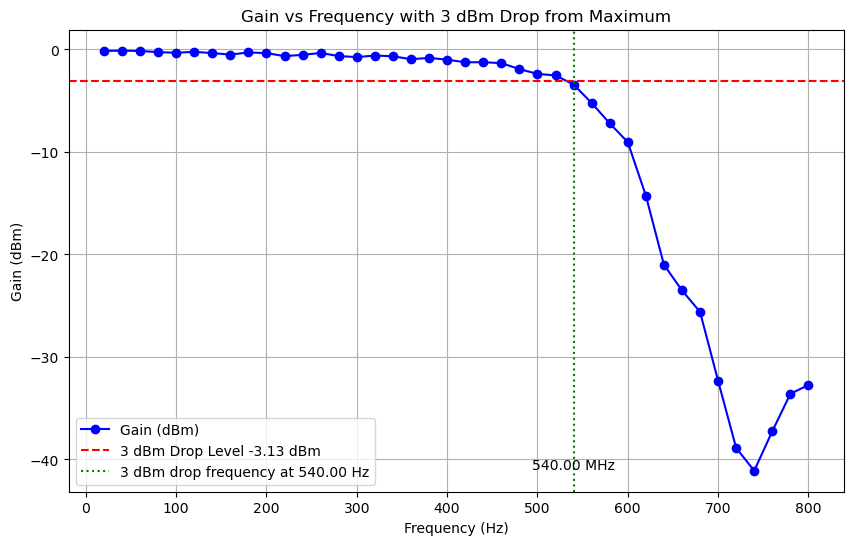

Frequencies at 3 dBm drop from the maximum gain:
540


In [34]:
# Find the maximum gain
max_gain = np.max(y_column)

# Calculate the 3 dBm drop from the maximum gain
drop_3db = max_gain - 3

# Find the x values (frequencies) where the gain drops by 3 dBm
indices = np.where(y_column <= drop_3db)[0][0]  # Indices where the gain is less than or equal to 3 dBm below the max
frequencies_at_3db = x_column[indices]

# Plot the original gain and the 3 dBm drop level
plt.figure(figsize=(10, 6))
plt.plot(x_column, y_column, label='Gain (dBm)', color='blue', marker='o')
plt.axhline(y=drop_3db, color='red', linestyle='--', label=f'3 dBm Drop Level {drop_3db:.2f} dBm')

# Draw vertical lines and annotate the corresponding x-values
#for i in indices:
fval = x_column[indices]
plt.axvline(x=x_column[indices], color='green', linestyle=':', ymax=(y_column[indices] - plt.ylim()[0]) , label = f"3 dBm drop frequency at {fval:.2f} Hz")  # Draw vertical line
plt.text(x_column[indices], y_column[indices] - 37.5, f'{x_column[indices]:.2f} MHz', color='black', ha='center')  # Annotate the x value

# Add labels, title, and legend
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain (dBm)')
plt.title('Gain vs Frequency with 3 dBm Drop from Maximum')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

# Print the frequencies at 3 dBm drop
print("Frequencies at 3 dBm drop from the maximum gain:")
print(frequencies_at_3db)

In [10]:
w0 = [200,500]
p0 = [-8.71,-8.3]

w = [300,700]
p = [-24.75,-23.73]

w_natural = [200,500]
p_natural = [-24.75,-77.67]



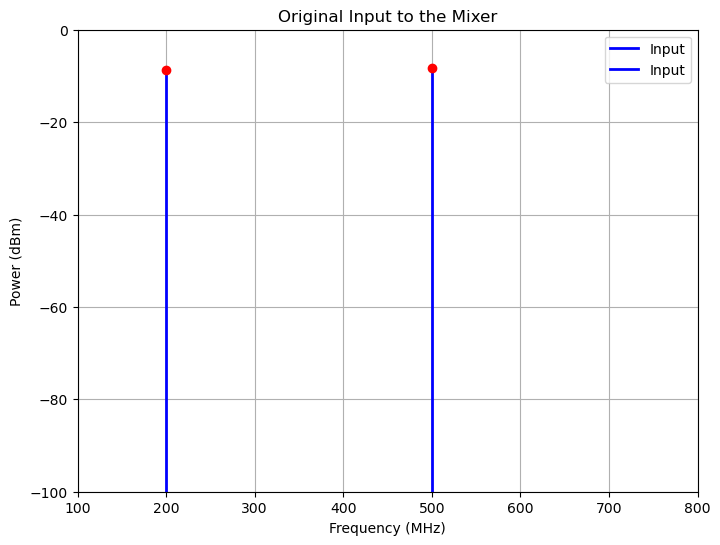

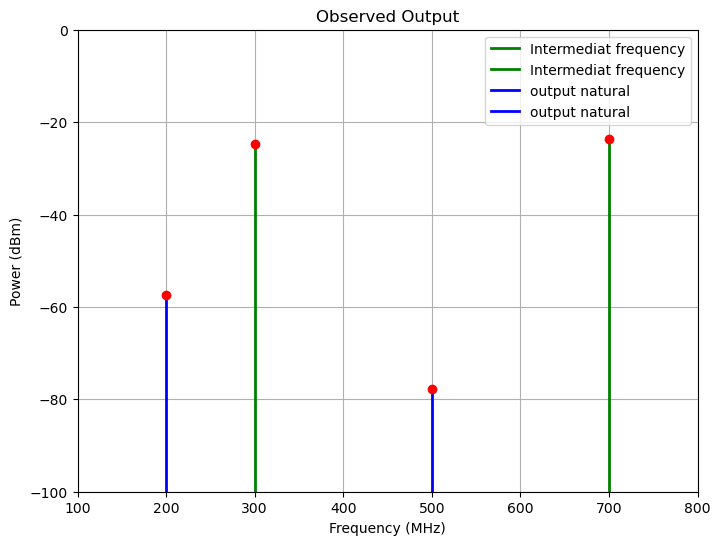

In [11]:
import matplotlib.pyplot as plt

# Data for original input frequencies and power
w0 = [200, 500]
p0 = [-8.71, -8.3]

# Data for observed frequencies and power through the mixer
w = [300, 700]
p = [-24.75, -23.73]

# Data for natural frequencies and power
w_natural = [200, 500]
p_natural = [-57.4, -77.67]

# Function to plot vertical lines from -100 dBm to the data points
def plot_spectrum(w, p, title,ls,l):
    
    # Plot vertical lines from -100 dBm to the respective points
    for i in range(len(w)):
        plt.plot([w[i], w[i]], [-100, p[i]], ls, lw=2, label =f"{l}" )
        plt.plot(w[i], p[i], 'ro')  # Plot the data point
    
    # Set plot title and labels
    plt.title(title)
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('Power (dBm)')
    plt.ylim([-100, 0])
    plt.xlim(100,800)
    plt.grid(True)
    plt.legend()
    
plt.figure(figsize=(8, 6))

# Plot for original input (w0, p0)
plot_spectrum(w0, p0, 'Original Input to the Mixer',"-b","Input")
plt.show()
plt.figure(figsize=(8, 6))

# Plot for observed output (w, p)
plot_spectrum(w, p, 'Observed Output: w and p',"-g","Intermediat frequency")

# Plot for natural frequencies (w_natural, p_natural)
plot_spectrum(w_natural, p_natural, 'Observed Output',"-b","output natural")
plt.show()

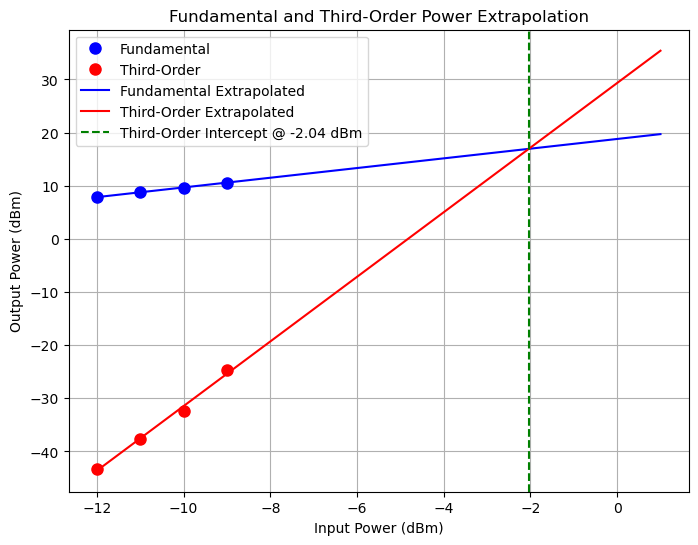

(-2.037158892974648, 16.938111089607123)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Given data
input_power = np.array([-12, -11, -10, -9])
third_order_power = np.array([-43.27, -37.62, -32.39, -24.75])
fundamental_power = np.array([7.8, 8.86, 9.64, 10.58])

# Linear regression for both fundamental and third-order powers
slope_fund, intercept_fund, _, _, _ = linregress(input_power, fundamental_power)
slope_third, intercept_third, _, _, _ = linregress(input_power, third_order_power)

# Extrapolating the lines
input_power_extrapolated = np.linspace(min(input_power), max(input_power) + 10, 100)

fundamental_extrapolated = slope_fund * input_power_extrapolated + intercept_fund
third_order_extrapolated = slope_third * input_power_extrapolated + intercept_third

# Finding the third-order intercept point
intercept_power = (intercept_fund - intercept_third) / (slope_third - slope_fund)
intercept_value_fund = slope_fund * intercept_power + intercept_fund
intercept_value_third = slope_third * intercept_power + intercept_third

# Plotting the results
plt.figure(figsize=(8,6))
plt.plot(input_power, fundamental_power, 'bo', label='Fundamental', markersize=8)
plt.plot(input_power, third_order_power, 'ro', label='Third-Order', markersize=8)
plt.plot(input_power_extrapolated, fundamental_extrapolated, 'b-', label='Fundamental Extrapolated')
plt.plot(input_power_extrapolated, third_order_extrapolated, 'r-', label='Third-Order Extrapolated')
plt.axvline(x=intercept_power, color='green', linestyle='--', label=f'Third-Order Intercept @ {intercept_power:.2f} dBm')
plt.title('Fundamental and Third-Order Power Extrapolation')
plt.xlabel('Input Power (dBm)')
plt.ylabel('Output Power (dBm)')
plt.legend()
plt.grid(True)

# Show plot
plt.show()

(intercept_power, intercept_value_fund)


In [13]:

# Load the Excel file
file_path = 'amplifier.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path, sheet_name='Sheet1')  # Load data from 'Sheet1'
print(df)
pout_array = df['pout.1'].to_numpy()

# Extract 'Pin' and 'Gain' columns into NumPy arrays
pin_array = df['pin'].to_numpy()
gain_array = (pout_array - pin_array)

# Print the arrays
print("Pin Array:", pin_array)
print("Gain Array:", gain_array)

# Input power and gain data (replace with your actual data)
power_in = pin_array
gain = gain_array
# Plot the data
plt.figure(figsize=(10,6))
plt.plot(power_in, gain, 'bo-', label='Measured Gain')
plt.xlabel('Input Power (dBm)')
plt.ylabel('Gain (dBm)')
plt.title('Input Power vs. Gain')

# Trend line for the first 10 points (small-signal gain region)
initial_power = power_in[:10]
initial_gain = gain[:10]

# Fit a linear trend line
slope, intercept, r_value, p_value, std_err = stats.linregress(initial_power, initial_gain)
trend_line = intercept + slope * power_in

# Plot the trend line
plt.plot(power_in, trend_line, 'r--', label='Trend Line (low input power)')

# Calculate the 1 dB compression point
compression_point = None
for i in range(10, len(gain)):
    expected_gain = intercept + slope * power_in[i]
    actual_gain = gain[i]
    if actual_gain <= expected_gain - 1:  # 1 dB compression condition
        compression_point = power_in[i]
        break

# Highlight the 1 dB compression point
if compression_point is not None:
    plt.axvline(compression_point, color='g', linestyle='--', label=f'1 dB Compression at {compression_point} dBm')
    plt.legend()

# Show plot
plt.grid(True)
plt.legend()
plt.show()

# Print the compression point
if compression_point is not None:
    print(f"1 dB Compression Point is at {compression_point} dBm")
else:
    print("1 dB Compression Point not found within the data range.")


FileNotFoundError: [Errno 2] No such file or directory: 'amplifier.xlsx'